Extra Code


In [192]:
'''
for z in unzip:
    print("\n"+ "="*80)
    print("ZipFile: ", z.name)

    with zipfile.ZipFile( z,"r" ) as zip_ref:
        names = zip_ref.namelist()
        print("Number of files inside:", len(names))
        print("First 20 files:")

        for name in names:
            print(" ", name)

print ("UNable to work")

def peek_csv_inside_zip(unzip, nrows=5):
    with zipfile.ZipFile(unzip, "r") as zip_ref:
        csv_files = [name for name in zip_ref.namelist() if name.endswith(".csv")]

        print("CSV files found:", len(csv_files))

        if not csv_files:
            print("No CSV files in this ZIP")
            return

        first_csv = csv_files[0]
        print("Opening:", first_csv)

        with zip_ref.open(first_csv) as file:
            df = pd.read_csv(file, nrows=nrows)

        print("\nColumns:")
        print(df.columns.tolist())

        print("\nShape of sample:")
        print(df.shape)

        print("\nData types:")
        print(df.dtypes)

        print("\nFirst rows:")
        print(df.head())

        return df

sample_df = peek_csv_inside_zip(unzip[0])

def inspect_zip (zip_path, max_files=30):
    print("\n"+ "="*80)
    print("ZipFile: ", zip_path.name)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        names = zip_ref.namelist()
        print("Total items inside", len(names))

        print("\nFirst files:")
        for  name in names[:max_files]:
            print(" ", names)
        filenames = [name for name in names if not name.endswith("/")]
        extensions= Counter(Path(name).suffix.lower() for name in filenames)
        print("\nFile types:")

        for ext, count in extensions.items():
            print(f"{ext if ext else '[no extension]'}: {count}")

for z in unzip:
    inspect_zip(z, max_files=20)
    '''


'\nfor z in unzip:\n    print("\n"+ "="*80)\n    print("ZipFile: ", z.name)\n\n    with zipfile.ZipFile( z,"r" ) as zip_ref:\n        names = zip_ref.namelist()\n        print("Number of files inside:", len(names))\n        print("First 20 files:")\n\n        for name in names:\n            print(" ", name)\n\nprint ("UNable to work")\n\ndef peek_csv_inside_zip(unzip, nrows=5):\n    with zipfile.ZipFile(unzip, "r") as zip_ref:\n        csv_files = [name for name in zip_ref.namelist() if name.endswith(".csv")]\n\n        print("CSV files found:", len(csv_files))\n\n        if not csv_files:\n            print("No CSV files in this ZIP")\n            return\n\n        first_csv = csv_files[0]\n        print("Opening:", first_csv)\n\n        with zip_ref.open(first_csv) as file:\n            df = pd.read_csv(file, nrows=nrows)\n\n        print("\nColumns:")\n        print(df.columns.tolist())\n\n        print("\nShape of sample:")\n        print(df.shape)\n\n        print("\nData types:")

Header  

In [193]:
from pathlib import Path
import pandas as pd
import zipfile
from collections import Counter
import matplotlib.pyplot as plt
import csv

Telecommand Dataset


In [194]:

datapath = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/telecommands/telecommand_1")
unzip = list(datapath.glob(".*zip"))
data_frame = pd.read_pickle(datapath)
print("Describe Telecommand\n", data_frame.describe())
unique_value = data_frame["telecommand_1"].nunique()
print("Unique Value in telecommand", unique_value)
check_status_diff = data_frame.index.to_series().diff()
print("Status diff series\n",check_status_diff)
print("The difference between the event_Channel_1\n",check_status_diff.value_counts().head(20))
print("Describe Difference in time of the event\n",check_status_diff.describe())


Describe Telecommand
        telecommand_1
count           15.0
mean             1.0
std              0.0
min              1.0
25%              1.0
50%              1.0
75%              1.0
max              1.0
Unique Value in telecommand 1
Status diff series
 2001-06-12 22:27:20.292                         NaT
2005-01-23 00:45:00.000   1320 days 02:17:39.708000
2005-01-23 01:38:26.496      0 days 00:53:26.496000
2005-04-01 07:28:24.984     68 days 05:49:58.488000
2005-05-10 23:52:51.177     39 days 16:24:26.193000
2005-09-02 18:24:13.740    114 days 18:31:22.563000
2005-09-28 10:19:24.249     25 days 15:55:10.509000
2005-10-22 23:02:28.104     24 days 12:43:03.855000
2007-04-14 13:24:17.235    538 days 14:21:49.131000
2007-04-14 20:01:15.039      0 days 06:36:57.804000
2009-05-26 11:57:34.428    772 days 15:56:19.389000
2009-05-26 12:00:46.998      0 days 00:03:12.570000
2009-05-30 10:21:43.518      3 days 22:20:56.520000
2009-05-30 10:27:42.915      0 days 00:05:59.397000
2010-12-17 

Channel Data


In [195]:


data_path = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/channels")
unzip = list(data_path.glob("*.zip"))

file_path = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/channels/channel_1")

df = pd.read_pickle(file_path)
#print(type(df))
#print(df.shape)
#print(df.head())
#print(df.tail())
#print(df.info())


print(df.describe())
print("Unique Values", df["channel_1"].nunique())
print(df["channel_1"].value_counts().head(20))


check_timeDiff = df.index.to_series().diff()

print(check_timeDiff.value_counts().head(20))
print(check_timeDiff.describe())

changes_channel_1 = df["channel_1"]

deviation = df[changes_channel_1.diff() != 0]
print(deviation.head(30)) 
print("number of value changed", len(deviation))

          channel_1
count  1.051334e+07
mean   1.380482e-01
std    5.039754e-03
min    9.217216e-02
25%    1.379103e-01
50%    1.379103e-01
75%    1.379103e-01
max    4.331867e-01
Unique Values 34550
channel_1
0.137910    10420729
0.139649       41213
0.150402        5449
0.144064        1498
0.321994        1248
0.377070         460
0.134432         249
0.171906         196
0.171257         148
0.092172         106
0.346973          93
0.363792          35
0.405034          32
0.137911          17
0.137910          17
0.137912          17
0.137910          14
0.137914          13
0.137913          12
0.137911          12
Name: count, dtype: int64
datetime
0 days 00:00:03           5090952
0 days 00:01:30           4659101
0 days 00:00:03.003000     221902
0 days 00:00:02.991000     166196
0 days 00:00:00.006000     125522
0 days 00:00:02.997000     117793
0 days 00:00:00.009000      61964
0 days 00:00:02.994000      29115
0 days 00:01:29.997000      11480
0 days 00:01:30.003000      1

### Understanding Meta Data


In [196]:
anamoly_types_path = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/anomaly_types.csv")
channels_path = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/channels.csv")
labels_path = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/labels.csv")
telecommand_path = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/telecommands.csv")

read_anamoly_types = pd.read_csv(anamoly_types_path)
read_channel = pd.read_csv(channels_path)
read_label_path = pd.read_csv(labels_path)
read_telecommand = pd.read_csv(telecommand_path)

In [197]:
data_frame_channel = pd.DataFrame(read_channel)
print(data_frame_channel)
#How many channels
no_of_channels = data_frame_channel["Channel"].nunique()
print("Number of Channels",no_of_channels)
no_of_target_channels = len(data_frame_channel[data_frame_channel["Target"]=="YES"])
print("Number of Target Channels",no_of_target_channels)
channel_name_target_channels = data_frame_channel[data_frame_channel["Target"]=="YES"]
print(channel_name_target_channels)

       Channel    Subsystem    Physical Unit  Group Target
0    channel_1  subsystem_1  physical_unit_1      1     NO
1    channel_2  subsystem_1  physical_unit_1      1     NO
2    channel_3  subsystem_1  physical_unit_1      1     NO
3    channel_4  subsystem_1  physical_unit_2      2     NO
4    channel_5  subsystem_1  physical_unit_2      2     NO
..         ...          ...              ...    ...    ...
71  channel_72  subsystem_3  physical_unit_4     18    YES
72  channel_73  subsystem_3  physical_unit_4     18    YES
73  channel_74  subsystem_3  physical_unit_4     18    YES
74  channel_75  subsystem_3  physical_unit_4     18    YES
75  channel_76  subsystem_3  physical_unit_4     18    YES

[76 rows x 5 columns]
Number of Channels 76
Number of Target Channels 58
       Channel    Subsystem    Physical Unit  Group Target
11  channel_12  subsystem_6  physical_unit_3      3    YES
12  channel_13  subsystem_6  physical_unit_3      3    YES
13  channel_14  subsystem_6  physical_uni

In [198]:
number_of_subsystems = data_frame_channel["Subsystem"].nunique()
print("Number of Subsystem",number_of_subsystems)

Number of Subsystem 4


In [199]:
number_of_physical_units = data_frame_channel["Physical Unit"].nunique()
print("Number of Physical Units", number_of_physical_units)

Number of Physical Units 6


In [200]:
labels = pd.DataFrame(read_label_path)
print(labels.count())


ID           3589
Channel      3589
StartTime    3589
EndTime      3589
dtype: int64


In [201]:
anamoly_types = pd.DataFrame(read_anamoly_types)
#print(anamoly_types)
different_anamoly_types = anamoly_types["Category"].unique()
print("Different Types of Anamoly\n",different_anamoly_types)

Different Types of Anamoly
 ['Rare Event' 'Anomaly' 'Communication Gap']


In [202]:
telecommand_priority = pd.DataFrame(read_telecommand)
number_of_priority = telecommand_priority.count()
print("Number of telecommand\n",number_of_priority)
unique_telecommand_priority = telecommand_priority["Priority"].unique()
print("Unique Telecommand Priority\n",unique_telecommand_priority)

Number of telecommand
 Telecommand    698
Priority       698
dtype: int64
Unique Telecommand Priority
 [1 2 3 0]


Channel Wise View Channel-12


In [203]:
Channel_12_load = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/channels/channel_12")
channel_12_read = pd.read_pickle(Channel_12_load)
#print(channel_12_read)


1. Metadata summary
   - Channel name
   - Subsystem
   - Physical unit
   - Group
   - Target: yes/no
   - Labelled: yes/no

In [204]:
sub_systems = read_channel.loc[read_channel["Channel"]== "channel_12", ["Channel","Subsystem","Physical Unit","Group","Target"]]
#print(sub_systems)
print("Name of the channel", sub_systems["Channel"])
print("SubSystem in channel 12", sub_systems["Subsystem"])
print("Physical Unit in channel 12", sub_systems["Physical Unit"])
print("Group in channel 12", sub_systems["Group"])
print("Target in channel 12", sub_systems["Target"])
is_Labelled = sub_systems["Channel"].isin(read_label_path["Channel"])
print(is_Labelled)

Name of the channel 11    channel_12
Name: Channel, dtype: object
SubSystem in channel 12 11    subsystem_6
Name: Subsystem, dtype: object
Physical Unit in channel 12 11    physical_unit_3
Name: Physical Unit, dtype: object
Group in channel 12 11    3
Name: Group, dtype: int64
Target in channel 12 11    YES
Name: Target, dtype: object
11    True
Name: Channel, dtype: bool


Time Range Summary Channel-12
   - Start time
   - End time
   - Number of rows
   - Memory size


In [205]:
start_time_label = read_label_path["StartTime"]
end_time_label = read_label_path["EndTime"]
number_of_rows = read_label_path.count()
#print(read_label_path.info())
#print("Number of Rows\n",number_of_rows)
#print("\nStart Time \n",start_time_label,"End Time\n",end_time_label)
read_label_path["StartTime"] = pd.to_datetime(read_label_path["StartTime"])
read_label_path["EndTime"] = pd.to_datetime(read_label_path["EndTime"])
read_label_path["correct_start_time"] = read_label_path["StartTime"].dt.strftime("%d-%b-%Y %H:%M")
read_label_path["correct_end_time"] = read_label_path["EndTime"].dt.strftime("%d-%b-%Y %H:%M")
read_label_path['correct_start_time_'] = read_label_path["correct_start_time"]
read_label_path['correct_end_time_'] = read_label_path["correct_end_time"]
read_label_path = read_label_path.drop(['StartTime','EndTime'],axis=1)
#print(read_label_path)
channel_12_label = read_label_path[read_label_path['Channel'] == "channel_12"]
#print(channel_12_label)


3. Value behaviour
   - describe()
   - unique value count
   - top 10 common values

In [225]:
print(channel_12_read.round(6).describe())
print(channel_12_read.head)
dataframe_channel_12_unique_value_count = channel_12_read.value_counts().head()
print("Top 10 Unique value Count\n",dataframe_channel_12_unique_value_count)

         channel_12
count  1.425851e+07
mean   2.465198e-01
std    4.422949e-02
min    1.225950e-01
25%    2.111150e-01
50%    2.423090e-01
75%    2.828610e-01
max    9.967710e-01
<bound method NDFrame.head of                          channel_12
datetime                           
2000-01-01 00:00:06.633    0.317175
2000-01-01 00:01:36.633    0.317175
2000-01-01 00:03:06.633    0.317175
2000-01-01 00:04:36.633    0.317175
2000-01-01 00:06:06.633    0.317175
...                             ...
2013-12-31 23:53:59.937    0.217355
2013-12-31 23:55:29.937    0.217355
2013-12-31 23:56:59.937    0.218915
2013-12-31 23:58:29.937    0.218915
2013-12-31 23:59:59.937    0.215795

[14258506 rows x 1 columns]>
Top 10 Unique value Count
 channel_12
0.198638      386530
0.207996      340691
0.203318      331304
0.240750      319521
0.304698      318108
Name: count, dtype: int64


4. Sampling behaviour
   - common time gaps
   - largest time gap
   - median time gap

In [223]:
common_time_gap = channel_12_read.index.to_series().diff()
common_time_gap.value_counts().head(20)
print(common_time_gap.max())
print(common_time_gap.median())

0 days 05:55:30
0 days 00:00:00.375000


5. Visual display
   - line plot over selected period
   - histogram/value distribution
   - change point plot/list


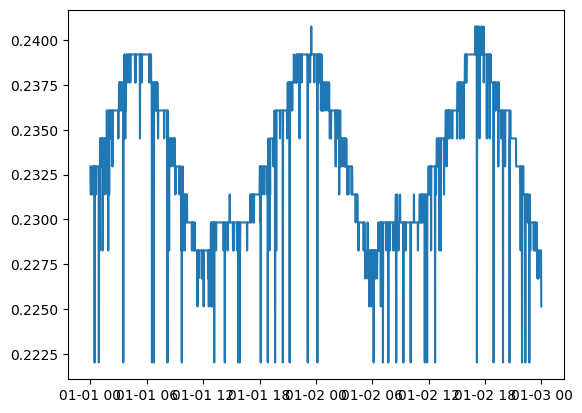

In [243]:
selected_period = channel_12_read.loc["2005-01-01":"2005-01-02"]
plt.plot(selected_period.index, selected_period["channel_12"])

(array([7.8700e+02, 5.5000e+01, 8.4900e+02, 5.2160e+03, 4.8950e+03,
        8.4910e+03, 1.0022e+04, 6.7520e+03, 1.2333e+04, 4.7560e+03,
        1.0923e+04, 4.6210e+03, 9.1840e+03, 9.4850e+03, 5.2590e+03,
        1.2512e+04, 6.0060e+03, 1.3807e+04, 1.4523e+04, 6.8200e+03,
        1.4046e+04, 5.6720e+03, 1.0191e+04, 5.2340e+03, 9.1330e+03,
        9.8500e+03, 4.5750e+03, 9.4170e+03, 5.2240e+03, 9.7530e+03,
        6.0190e+03, 1.4607e+04, 1.3940e+04, 7.9490e+03, 1.7220e+04,
        9.5130e+03, 2.4417e+04, 1.3926e+04, 6.5150e+03, 8.4400e+03,
        2.2480e+03, 2.0200e+02, 5.7000e+01, 5.6000e+01, 9.9000e+01,
        4.1000e+01, 5.1000e+01, 1.6000e+01, 3.1000e+01, 2.5000e+01]),
 array([0.22203273, 0.22449705, 0.22696137, 0.22942571, 0.23189004,
        0.23435436, 0.23681869, 0.23928303, 0.24174735, 0.24421167,
        0.246676  , 0.24914034, 0.25160465, 0.25406897, 0.25653332,
        0.25899765, 0.26146197, 0.2639263 , 0.26639062, 0.26885495,
        0.27131927, 0.27378362, 0.27624795, 0.

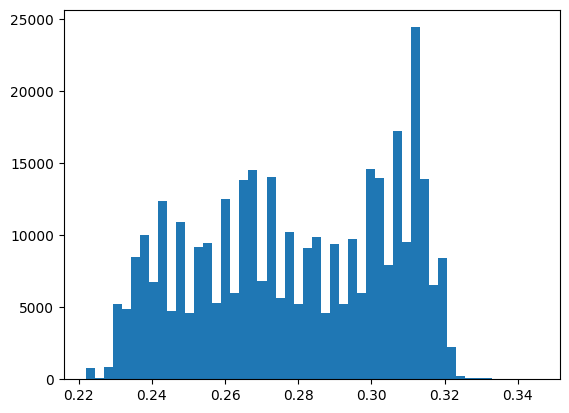

In [236]:
plt.hist(selected_period["channel_12"].dropna(), bins=50)

In [242]:
changes = selected_period[selected_period["channel_12"].diff().abs() > 0]
print(changes)

threshold = selected_period["channel_12"].std()
print("threshold",threshold)
changes = selected_period[selected_period["channel_12"].diff().abs() > threshold]
print(changes)

                         channel_12
datetime                           
2005-01-01 00:01:45.426    0.231392
2005-01-01 00:12:15.426    0.232952
2005-01-01 00:19:45.426    0.231392
2005-01-01 00:21:15.426    0.232952
2005-01-01 00:22:45.426    0.231392
...                             ...
2005-12-31 23:25:12.378    0.314055
2005-12-31 23:32:42.378    0.312495
2005-12-31 23:34:12.378    0.314055
2005-12-31 23:44:42.378    0.309375
2005-12-31 23:46:12.378    0.314055

[113432 rows x 1 columns]
threshold 0.026654176
Empty DataFrame
Columns: [channel_12]
Index: []


6. Context display, optional
   - labelled interval shading
   - telecommand vertical lines